In [1]:
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns  # optional, just for color if you like
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import statsmodels.formula.api as smf
import math

In [2]:
meta = pd.read_csv("/Users/seohyon/resources/Batch_Integration_Dataset - Copy of Tabellenblatt3.csv")
meta

,dataset,organism,n_tissues,size,n_genes,n_celltypes,n_batches,batch_imbalance_gc,nested_batches,n_donors
0,mouse_pancreas_atlas,Mouse,1,301796,31334,20,56,0.354691,Yes,56
1,dkd,Human,1,39176,36503,13,11,0.266559,No,11
2,immune_cell_atlas,Human,17,329762,36503,35,12,0.460000,Yes,12
3,gtex_v9,Human,8,209126,32922,53,16,0.494784,Yes,16
4,hypomap,Mouse,1,384925,51811,13,24,0.908038,No,24
5,tabula_sapiens,Human,45,483152,58604,160,15,0.658615,No,15


In [6]:
meta.columns

Index(['dataset', 'organism', 'n_tissues', 'size', 'n_genes', 'n_celltypes',
       'n_batches', 'batch_imbalance_gc', 'nested_batches', 'n_donors'],
      dtype='object')

/var/folders/hn/2jsgf5g54l9glw98f7345cb00000gn/T/ipykernel_17672/1108863679.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=meta, x=col, ax=axes[i], order=order, palette='Set2')
/var/folders/hn/2jsgf5g54l9glw98f7345cb00000gn/T/ipykernel_17672/1108863679.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=meta, x=col, ax=axes[i], order=order, palette='Set2')


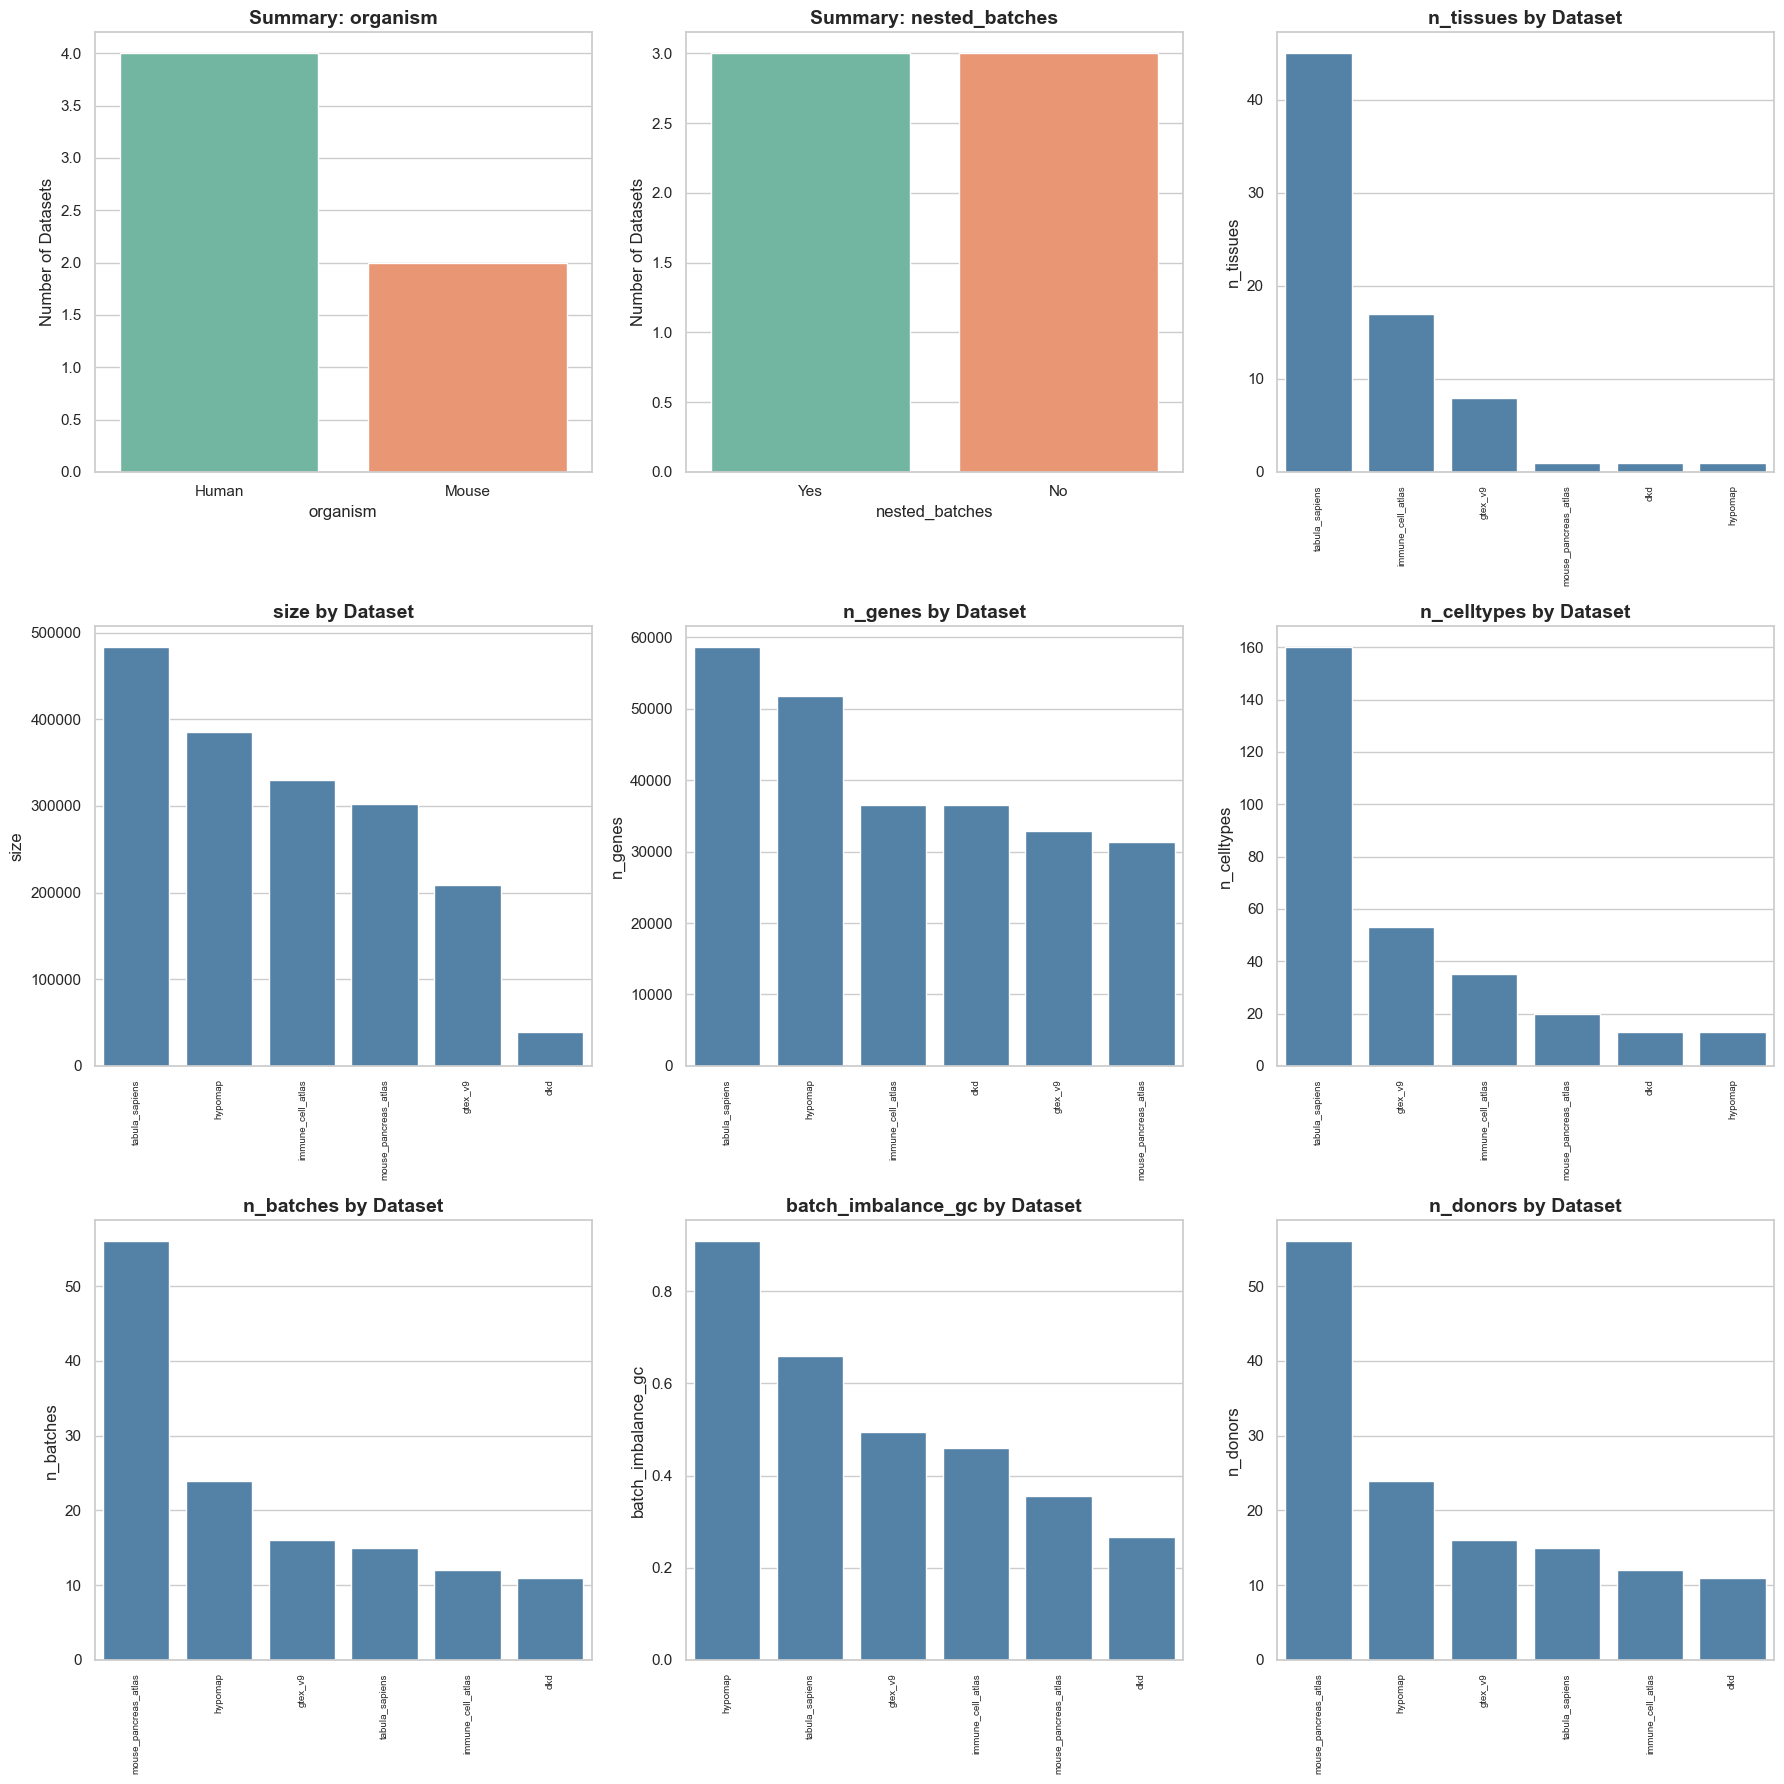

In [11]:
# Define all 9 columns for the 3x3 grid
cols_to_plot = [
    'organism', 'nested_batches', 'n_tissues', 
    'size', 'n_genes', 'n_celltypes', 
    'n_batches', 'batch_imbalance_gc', 'n_donors'
]

# Grid configuration: 3x3 = 9 plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(18, 18)) # 18x18 for a large square grid
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    # CATEGORICAL SUMMARY: Only for these two specific columns
    if col in ['organism', 'nested_batches']:
        order = meta[col].value_counts().index
        sns.countplot(data=meta, x=col, ax=axes[i], order=order, palette='Set2')
        axes[i].set_ylabel('Number of Datasets')
        axes[i].set_title(f'Summary: {col}', fontsize=14, fontweight='bold')
    
    # NUMERICAL METRICS: Per-dataset breakdown for everything else
    else:
        # Sorting by value to make the dataset comparison clearer
        df_sorted = meta.sort_values(by=col, ascending=False)
        sns.barplot(data=df_sorted, x='dataset', y=col, ax=axes[i], color='steelblue')
        
        axes[i].set_title(f'{col} by Dataset', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('')
        # Hide x-labels if they get too crowded, or rotate them
        axes[i].tick_params(axis='x', rotation=90, labelsize=7)

plt.tight_layout()
plt.savefig('/Users/seohyon/Downloads/meta_distributions.png')
plt.show()

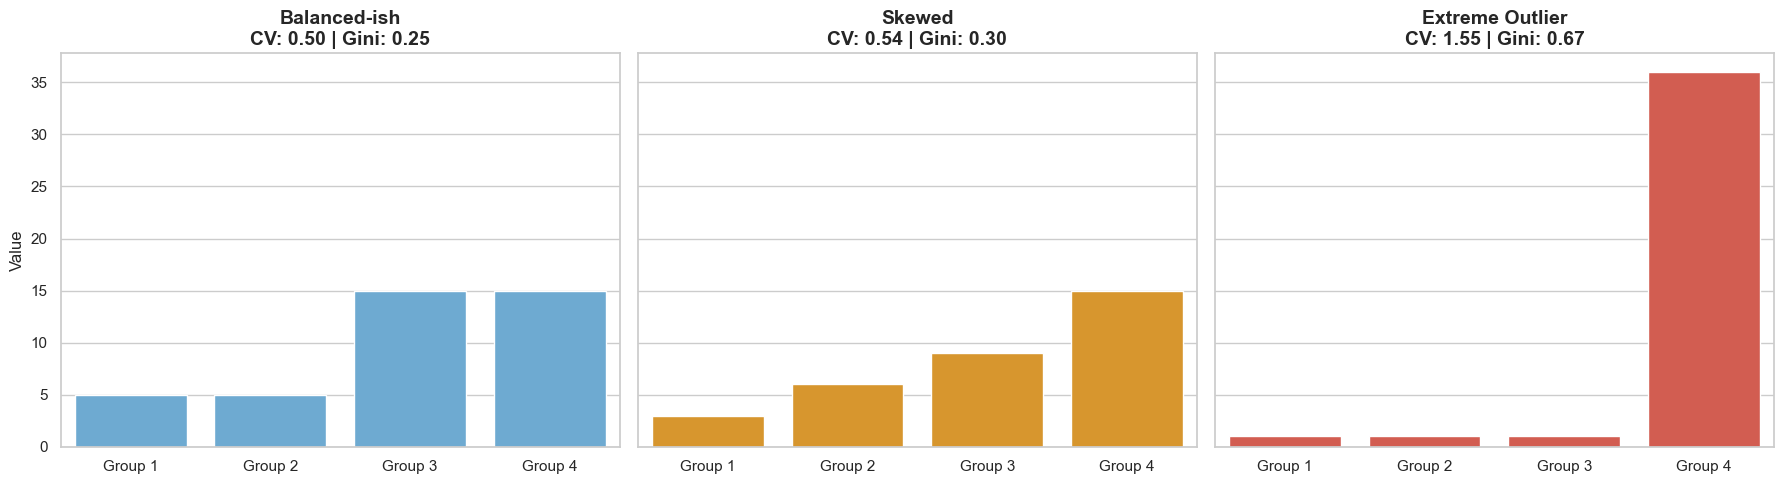

In [20]:
def gini_py(values):
    """
    Compute the Gini coefficient of a list of non-negative numbers.
    Pure Python implementation (no NumPy).
    """
    values = list(values)

    if any(v < 0 for v in values):
        raise ValueError("All values must be non-negative.")

    if all(v == 0 for v in values):
        return 0.0

    # Sort values
    values.sort()
    n = len(values)
    total = sum(values)

    cumulative = 0
    weighted_sum = 0
    for i, v in enumerate(values, start=1):
        weighted_sum += (2 * i - n - 1) * v

    return weighted_sum / (n * total)

def get_cv(x):
    return np.std(x) / np.mean(x)

# Data from your example
dist_a = np.array([5, 5, 15, 15])
dist_b = np.array([3, 6, 9, 15])
dist_c = np.array([1, 1, 1, 36])

# Calculate stats
stats = {
    "Balanced-ish": {"data": dist_a, "cv": get_cv(dist_a), "gini": gini_py(dist_a)},
    "Skewed": {"data": dist_b, "cv": get_cv(dist_b), "gini": gini_py(dist_b)},
    "Extreme Outlier": {"data": dist_c, "cv": get_cv(dist_c), "gini": gini_py(dist_c)}
}

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = ['#5dade2', '#f39c12', '#e74c3c']

for i, (name, s) in enumerate(stats.items()):
    sns.barplot(x=[f"Group {j+1}" for j in range(4)], y=s['data'], ax=axes[i], color=colors[i])
    axes[i].set_title(f"{name}\nCV: {s['cv']:.2f} | Gini: {s['gini']:.2f}", fontsize=14, fontweight='bold')
    axes[i].set_ylabel("Value" if i==0 else "")
    

plt.tight_layout()
plt.show()

In [21]:
base_dir = "/Users/seohyon/resources/results"

# will track only these methods (above BBKNN)
keep_methods = [
    "embed_cell_types_jittered",
    "embed_cell_types",
    "shuffle_integration",
    "shuffle_integration_by_cell_type",
    "shuffle_integration",
    "scanvi",
    "combat",
    "scvi",
    "harmony",
    "harmonypy",
    "batchelor_fastmnn",
    "liger",
    "pyliger",
    "scalex",
    "uce",
    "no_integration",
    "no_integration_batch",
    "scanorama"
]

yaml_path = "/Users/seohyon/resources/results/run_2025-10-11_13-28-50/score_uns.yaml"
rows = []

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

for entry in data:
    method = entry.get("method_id", "").strip().lower()

    # keep only desired methods
    if method not in keep_methods:
        continue

    metrics = entry.get("metric_ids", [])
    values = entry.get("metric_values", [])

    for m_id, m_val in zip(metrics, values):
        rows.append({
            "dataset_id": entry.get("dataset_id"),
            "method_id": method,
            "metric_id": m_id,
            "metric_value": m_val
        })
        
df = pd.DataFrame(rows)
df = df.dropna(subset=["metric_value"]).copy() # drop NaN
# df = df[df["metric_id"] != "kbet"].copy() # drop kbet
df = df[~df["metric_id"].isin(["kbet", "hvg_overlap"])].copy() # drop unwanted metrics
df["dataset_id"] = df["dataset_id"].str.split("/").str[-1] # clean the dataset id

df = pd.merge(df, meta, left_on="dataset_id", right_on="dataset", how="inner").drop(columns=["dataset"])

control_type_map = {
    "embed_cell_types": "positive",
    "embed_cell_types_jittered": "positive",
    "shuffle_integration": "negative",
    "shuffle_integration_by_batch": "negative",
    "shuffle_integration_by_cell_type": "negative",
    "no_integration": "baseline",
    "no_integration_batch": "baseline",
}

df["control_type"] = df["method_id"].map(control_type_map).fillna("non-control")
df["control_group"] = df["control_type"].apply(
    lambda x: "non-control method" if x == "non-control" else "control method"
)

# mapping categorical to binary for plotting
df["nested_batches_num"] = df["nested_batches"].map({"No": 0, "Yes": 1})

bio_metrics = [
    'ari',
    'nmi',
    'clisi',
    'cell_cycle_conservation',
    'asw_label',
    'isolated_label_f1',
    'isolated_label_asw',
]

batch_metrics = [
    'pcr',
    'graph_connectivity',
    'ilisi',
    'asw_batch',
    'kbet_pg',
    'kbet_pg_label',
    'ari_batch',
    'nmi_batch',
]

def categorize_metric(m):
    if m in bio_metrics:
        return "bio"
    if m in batch_metrics:
        return "batch"
    return "baseline"

df["metric_type"] = df["metric_id"].apply(categorize_metric)

baseline = df[df["metric_type"] == "baseline"]
non_baseline = df[df["metric_type"] != "baseline"]

# For non-baseline, the metric_group is just metric_type ("bio" or "batch")
non_baseline = non_baseline.assign(metric_group=non_baseline["metric_type"])

# Duplicate baseline rows: one copy for "bio", one for "batch"
baseline_bio = baseline.copy()
baseline_bio["metric_group"] = "bio"

baseline_batch = baseline.copy()
baseline_batch["metric_group"] = "batch"

# Combine everything
df = pd.concat(
    [non_baseline, baseline_bio, baseline_batch],
    ignore_index=True
)

In [23]:
df.columns

Index(['dataset_id', 'method_id', 'metric_id', 'metric_value', 'organism',
       'n_tissues', 'size', 'n_genes', 'n_celltypes', 'n_batches',
       'batch_imbalance_gc', 'nested_batches', 'n_donors', 'control_type',
       'control_group', 'nested_batches_num', 'metric_type', 'metric_group'],
      dtype='object')

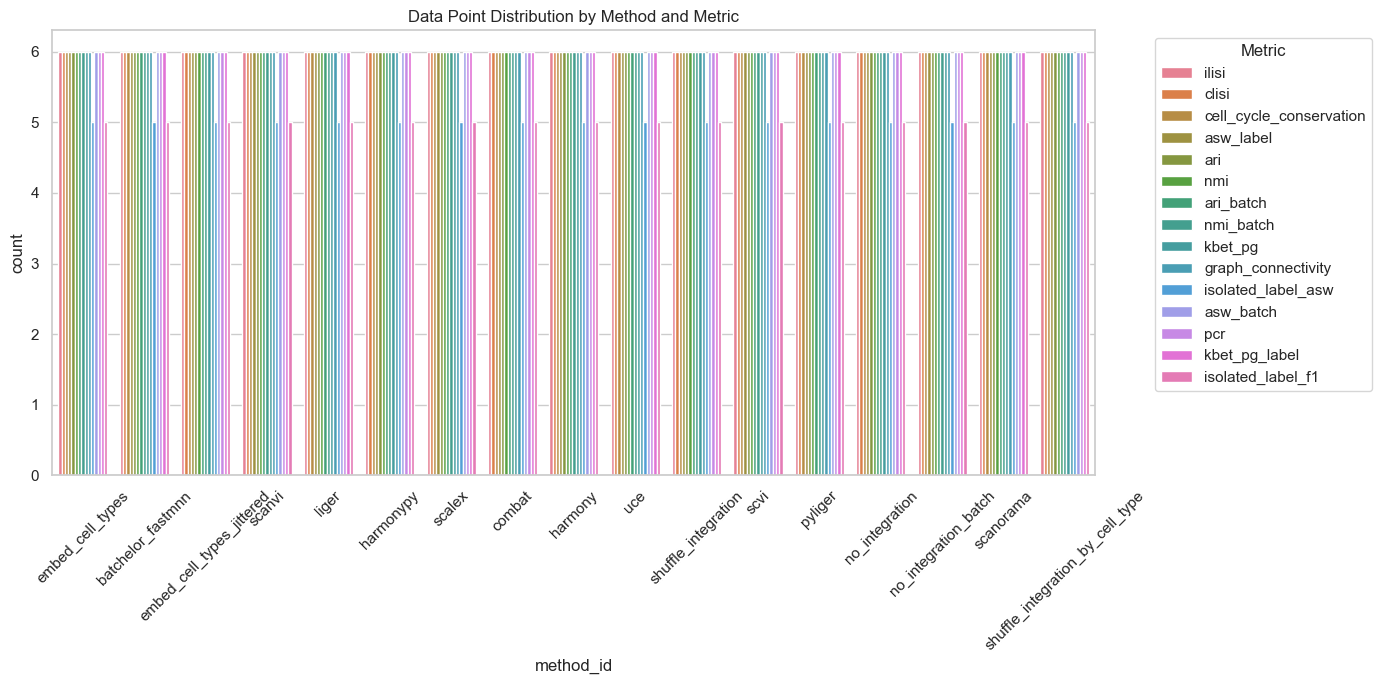

In [24]:
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='method_id', hue='metric_id')
plt.title('Data Point Distribution by Method and Metric')
plt.xticks(rotation=45)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()